Task 1

In [3]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")
df.head()
df.shape
df.info()
df.describe()
df.dtypes
print(df["is_canceled"].value_counts())
print(df["is_canceled"].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\baidm\AppData\Local\Temp\ipykernel_19984\3046733034.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


Task 2

In [7]:
missing_count = X.isna().sum()
missing_pct = (X.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_summary

,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [10]:
if "company" in X.columns:
    X = X.drop(columns=["company"])

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("company" in X.columns)
print(X.shape)

False
(119390, 30)


C:\Users\baidm\AppData\Local\Temp\ipykernel_19984\4171842694.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


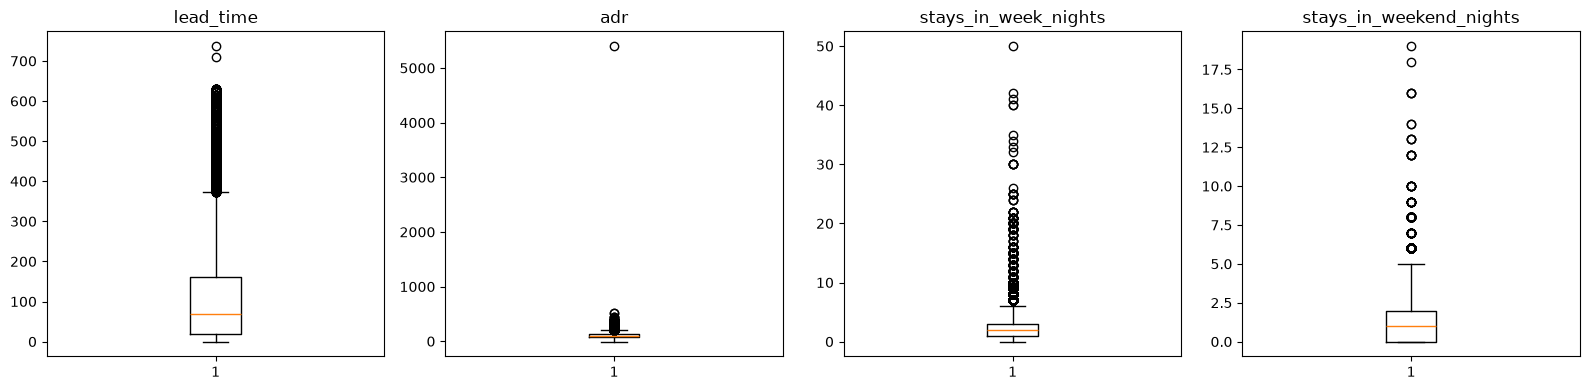

In [11]:
import matplotlib.pyplot as plt

outlier_check_cols = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights"]

fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_check_cols):
    ax.boxplot(X[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [12]:
rows_before = len(X)

for col in outlier_check_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    mask = (X[col] >= lower) & (X[col] <= upper) | X[col].isna()
    X = X[mask]
    y = y[X.index]

rows_after = len(X)
print(f"Rows removed: {rows_before - rows_after}")
print(f"Rows before: {rows_before}, Rows after: {rows_after}")

Rows removed: 1950
Rows before: 119390, Rows after: 117440


Task 3

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numerical_transformer_A = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

preprocessor_A = ColumnTransformer(transformers=[
    ("num", numerical_transformer_A, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

numerical_transformer_B = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

preprocessor_B = ColumnTransformer(transformers=[
    ("num", numerical_transformer_B, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

(93952, 28) (23488, 28)
is_canceled
0    0.630343
1    0.369657
Name: proportion, dtype: float64
is_canceled
0    0.630322
1    0.369678
Name: proportion, dtype: float64


Task 4

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

model_A_logreg = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

model_B_logreg = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

model_A_tree = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

model_B_tree = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

model_A_logreg.fit(X_train, y_train)
print("Model A + LogReg trained")

model_B_logreg.fit(X_train, y_train)
print("Model B + LogReg trained")

model_A_tree.fit(X_train, y_train)
print("Model A + Tree trained")

model_B_tree.fit(X_train, y_train)
print("Model B + Tree trained")

Model A + LogReg trained
Model B + LogReg trained
Model A + Tree trained
Model B + Tree trained


Task 5

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "LogReg + StandardScaler (A)": model_A_logreg,
    "LogReg + MinMaxScaler (B)": model_B_logreg,
    "DecisionTree + StandardScaler (A)": model_A_tree,
    "DecisionTree + MinMaxScaler (B)": model_B_tree,
}

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-Score": f1_score(y_test, test_pred),
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,LogReg + StandardScaler (A),0.818822,0.813990,0.802525,0.658989,0.723708
1,LogReg + MinMaxScaler (B),0.815172,0.812117,0.802151,0.652770,0.719792
2,DecisionTree + StandardScaler (A),0.996179,0.858779,0.806699,0.812738,0.809707
3,DecisionTree + MinMaxScaler (B),0.996179,0.859034,0.807112,0.812968,0.810029


In [28]:
print("reservation_status" in X.columns)
print("reservation_status_date" in X.columns)
print(X.columns.tolist())

False
False
['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [29]:
leakage_cols = ["reservation_status", "reservation_status_date"]
existing_leakage = [c for c in leakage_cols if c in X.columns]
X = X.drop(columns=existing_leakage)

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Dropped:", existing_leakage)
print(X.shape)
print("reservation_status" in X.columns)
print("reservation_status_date" in X.columns)

Dropped: []
(117440, 28)
False
False


C:\Users\baidm\AppData\Local\Temp\ipykernel_19984\3397865131.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(93952, 28) (23488, 28)
is_canceled
0    0.630343
1    0.369657
Name: proportion, dtype: float64
is_canceled
0    0.630322
1    0.369678
Name: proportion, dtype: float64


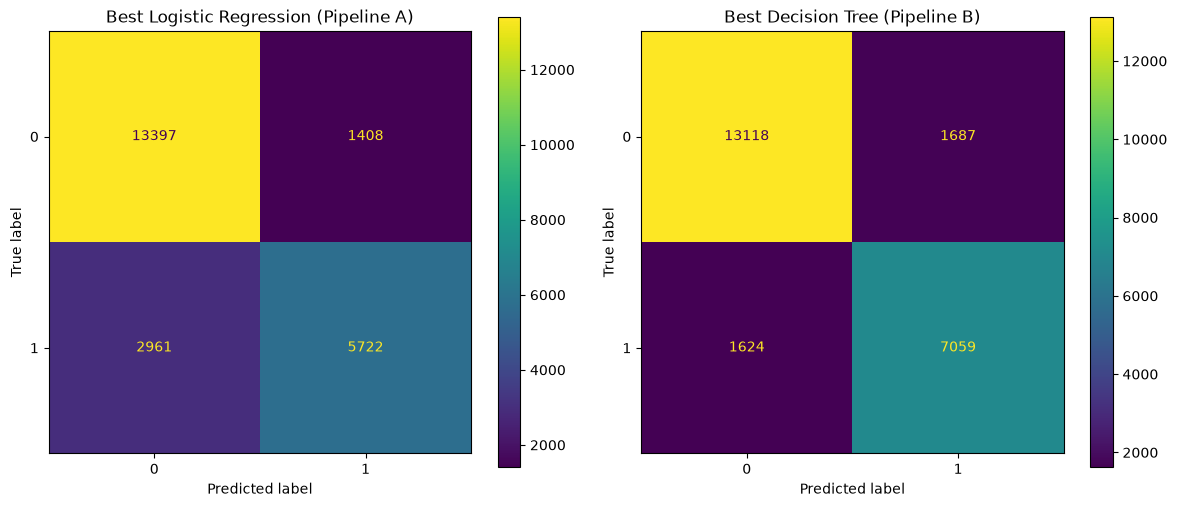

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_logreg = model_A_logreg   # Pipeline A: 0.8140 test acc, beats B's 0.8121
best_tree = model_B_tree       # Pipeline B: 0.8590 test acc, beats A's 0.8588

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(best_logreg, X_test, y_test, ax=axes[0])
axes[0].set_title("Best Logistic Regression (Pipeline A)")

ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, ax=axes[1])
axes[1].set_title("Best Decision Tree (Pipeline B)")

plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()

- Logistic Regression generalizes well: training accuracy (81.88%) and test accuracy (81.40%) for Pipeline A are almost identical, meaning the model isn't overfitting — it's learning patterns that hold up on unseen data.
- Decision Tree overfits noticeably: training accuracy is 99.6%, but test accuracy drops to ~85.9% — a ~14-point gap. This shows the tree has memorized details specific to the training set, including noise, rather than learning only patterns that generalize.
- Decision Tree still wins overall despite overfitting: even with the gap, it beats Logistic Regression on both test accuracy and F1-score, suggesting it's capturing genuine signal in the data — just mixed in with some memorization.
- Takeaway: Logistic Regression is more stable/reliable in the sense of train-test consistency, while the Decision Tree is more powerful but less trustworthy without some form of regularization (e.g., limiting tree depth) to control the overfitting.


# Task 6

- Logistic Regression basically performs the same on training and test data — 81.88% vs 81.40%. That's actually reassuring. It means the model isn't cheating by memorizing answers, it's genuinely learning something that carries over to new bookings.

- The Decision Tree, though, is where things get interesting. On training data it's almost perfect — 99.6% — but the moment it sees the test set, that drops to about 85.9%. A 14-point fall like that is basically the model saying "I memorized my homework but wasn't actually tested on it." Classic overfitting.

- And yet, weirdly, the Decision Tree still beats Logistic Regression on test accuracy and F1-score. So it's not a total loss — it clearly did learn some real patterns along the way, they're just buried under a layer of memorization.

- If I had to sum it up: Logistic Regression is the more trustworthy of the two — what you see in training is what you get in practice. The Decision Tree has more raw power but needs to be reined in a bit (shallower depth, some pruning) before it's something you'd actually rely on.